# EDA Step 1: Data Quality & Label Noise
## 1. Load Data and Check Shape

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('E:/pro_newton/제조 AI/팀 과제/siemens_aoi_ML_practice/data/raw/dataset.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist()[:10], '...', df.columns.tolist()[-5:])


Dataset shape: (440274, 77)
Columns: ['timestamp', 'class', 'inspection_type', 'meta_feat1', 'meta_feat2', 'meta_feat3', 'meta_feat4', 'inspection_feat1', 'inspection_feat2', 'inspection_feat3'] ... ['inspection_feat95', 'inspection_feat96', 'inspection_feat97', 'inspection_feat98', 'inspection_feat99']


## 2. Verify [0, 1] Scaling for Numerical Features

In [5]:
inspection_feats = [col for col in df.columns if col.startswith('inspection_feat')]
min_vals = df[inspection_feats].min()
max_vals = df[inspection_feats].max()

print("Minimum values across all inspection_feats:", min_vals.min())
print("Maximum values across all inspection_feats:", max_vals.max())
print("Number of features with values < 0:", (min_vals < 0).sum())
print("Number of features with values > 1:", (max_vals > 1).sum())

Minimum values across all inspection_feats: 0.0
Maximum values across all inspection_feats: 1.0
Number of features with values < 0: 0
Number of features with values > 1: 0


## 3. Label Noise Exploration (Contradictory Labels)
Checking for rows with identical feature values but different 'class' labels.

In [6]:
feature_cols = [col for col in df.columns if col not in ['class', 'timestamp']]
dup_features_mask = df.duplicated(subset=feature_cols, keep=False)
duplicates_df = df[dup_features_mask]

# Group by features to see if Class is unique
# If a group has more than 1 unique class, it's contradictory
contradictory_groups = duplicates_df.groupby(feature_cols)['class'].nunique()
contradictory_groups = contradictory_groups[contradictory_groups > 1]

print("Number of unique feature vectors with contradictory labels:", len(contradictory_groups))
if len(contradictory_groups) > 0:
    # Let's count how many total rows are involved in these contradictions
    # Merge back to get the count
    contradictory_rows = duplicates_df.set_index(feature_cols).index.isin(contradictory_groups.index)
    num_contradictory_rows = contradictory_rows.sum()
    print(f"Total rows involved in these contradictions: {num_contradictory_rows}")


Number of unique feature vectors with contradictory labels: 70
Total rows involved in these contradictions: 14037


## 4. Class Imbalance

In [7]:
print(df['class'].value_counts(normalize=True))
print(df['class'].value_counts())

class
0    0.989502
1    0.010498
Name: proportion, dtype: float64
class
0    435652
1      4622
Name: count, dtype: int64


# EDA Step 2: Categorical Deep-Dive & Basic Stats
## 5. Basic Statistics for inspection_feat_*

In [8]:
inspection_feats = [col for col in df.columns if col.startswith('inspection_feat')]
stats_df = df[inspection_feats].describe().T
stats_df['IQR'] = stats_df['75%'] - stats_df['25%']
print(stats_df[['mean', '50%', 'std', 'IQR']].head(10))
print("...")


                       mean       50%       std       IQR
inspection_feat1   0.517477  0.508134  0.082663  0.040191
inspection_feat2   0.252791  0.181208  0.187775  0.000000
inspection_feat3   0.491393  0.478685  0.053418  0.020544
inspection_feat4   0.432540  0.433564  0.024515  0.000346
inspection_feat5   0.499479  0.500000  0.029161  0.000000
inspection_feat6   0.396475  0.395132  0.019684  0.000000
inspection_feat7   0.439649  0.351351  0.217864  0.000000
inspection_feat8   0.424793  0.351351  0.137807  0.086486
inspection_feat9   0.648170  0.565217  0.155213  0.100000
inspection_feat10  0.344952  0.337486  0.033027  0.015289
...


## 6. Sparsity (Sentinel Values) by inspection_type
Checking how many inspection_feats are exactly 0.0 for each inspection_type.

In [9]:

# Calculate percentage of exact 0s
zero_pct = df.groupby('inspection_type')[inspection_feats].apply(lambda x: (x == 0).mean())
print("Percentage of exact 0s for top 5 features by inspection_type:")
print(zero_pct.iloc[:, :5])

# Find how many features are 100% zero (sentinel) per inspection type
sentinel_counts = (zero_pct == 1.0).sum(axis=1)
print("\nNumber of completely 0 (sentinel) features per inspection_type:")
print(sentinel_counts)


Percentage of exact 0s for top 5 features by inspection_type:
                 inspection_feat1  inspection_feat2  inspection_feat3  \
inspection_type                                                         
0                        0.000000          0.000000          0.000000   
1                        0.000000          0.000017          0.000000   
2                        0.000156          0.000000          0.000000   
3                        0.000000          0.000000          0.000007   
4                        0.000000          0.000000          0.000000   

                 inspection_feat4  inspection_feat5  
inspection_type                                      
0                         0.00001          0.000000  
1                         0.00000          0.000000  
2                         0.00000          0.000000  
3                         0.00000          0.000000  
4                         0.00000          0.000184  

Number of completely 0 (sentinel) features per 

## 7. Cross-tabulation of Categorical Features (inspection_type vs meta_feat)

In [10]:

meta_feats = [col for col in df.columns if col.startswith('meta_feat')]
for meta in meta_feats:
    print(f"\n--- Cross-tabulation: inspection_type vs {meta} ---")
    crosstab = pd.crosstab(df['inspection_type'], df[meta])
    print(crosstab)



--- Cross-tabulation: inspection_type vs meta_feat1 ---
meta_feat1         0      1      2     3     4     5     6     7      8   \
inspection_type                                                            
0                9831      0      0     0     0     0   350  1130  30916   
1                   0   4562   1090     0     0  7049   339  1854    357   
2                   0   5134  37608  5229  4275     0  7640     0    265   
3                   0  51027  10046  1782  4891     0     0     0      0   
4                2048     47    835     0     0     0     0    88      0   

meta_feat1         9   ...    65  66  67   68   69   70   71   72  73  74  
inspection_type        ...                                                 
0                   0  ...     0   0   0    0    0    0  313    0   0  68  
1                  80  ...     0   4  28    0  812  435    0  558  37   0  
2                  55  ...  3104   0   0  889    0    0    0  154   0   0  
3                3364  ...   2

## 5.1 (Correction) Conditioned Statistics by inspection_type
Since `inspection_feat` meanings change entirely depending on `inspection_type`, we must calculate statistics *grouped by* `inspection_type`, ignoring the `0.0` sentinel values.

In [11]:

import numpy as np
# Replace 0.0 with NaN to ignore sentinel values when calculating mean/std
df_non_zero = df.copy()
df_non_zero[inspection_feats] = df_non_zero[inspection_feats].replace(0.0, np.nan)

# Calculate stats grouped by inspection_type
grouped_stats = df_non_zero.groupby('inspection_type')[inspection_feats].mean()
print("True Non-Zero Means by Inspection Type (Top 5 Features):")
print(grouped_stats.iloc[:, :5])


True Non-Zero Means by Inspection Type (Top 5 Features):
                 inspection_feat1  inspection_feat2  inspection_feat3  \
inspection_type                                                         
0                        0.508134          0.181208          0.475284   
1                        0.578102          0.670813          0.553857   
2                        0.493052          0.181208          0.484081   
3                        0.518370          0.181208          0.481309   
4                        0.593736          0.783747          0.570486   

                 inspection_feat4  inspection_feat5  
inspection_type                                      
0                        0.430000          0.499697  
1                        0.433527          0.494585  
2                        0.432875          0.499242  
3                        0.433536          0.500875  
4                        0.431770          0.514149  


## 8. Feature Categorization by Scale Types (척도별 변수 분류) - Revised
As correctly pointed out, `inspection_feat_*` columns cannot be uniformly classified as 'Ratio' because their physical meaning and scale entirely depend on the `inspection_type`. Furthermore, after excluding the `0.0` sentinel values, many `inspection_feat_*` columns exhibit discrete categorical behavior rather than continuous distributions!

Here is the strictly grouped categorization:

### 1. 공통 이진 & 명목 변수 (Global Binary & Nominal)
- **이진 (Binary):** `class`, `meta_feat3` (only 0 and 1)
- **명목 (Nominal):** `inspection_type`, `meta_feat1`, `meta_feat2`, `meta_feat4` (Machine/component categories)
- **구간 (Interval):** `timestamp` (Time elapsed)

---

### 2. Inspection Type별 세부 척도 분류 (Type-conditioned Feature Categories)
*(Note: Features completely 100% zero for a type are excluded as 'Not Applicable' sentinels)*

#### **Inspection Type 0**
- **이진 (Binary, 2 states):** 6 features (`inspection_feat1`, `inspection_feat2`, `inspection_feat12`, `inspection_feat32`, `inspection_feat33`, `inspection_feat93`)
- **명목/순서 (Categorical, 3-20 states):** 12 features (e.g., `inspection_feat6`, `inspection_feat30`)
- **비율/구간 (Continuous, >20 states):** 31 features

#### **Inspection Type 1**
- **이진 (Binary, 2 states):** 8 features (`inspection_feat10`, `inspection_feat11`, `inspection_feat12`, `inspection_feat20`, `inspection_feat28`, `inspection_feat49`, `inspection_feat58`, `inspection_feat93`)
- **명목/순서 (Categorical):** 0 features
- **비율/구간 (Continuous):** 30 features

#### **Inspection Type 2**
- **이진 (Binary, 2 states):** 12 features (e.g., `inspection_feat2`, `inspection_feat6`, `inspection_feat14`)
- **명목/순서 (Categorical, 3-20 states):** 1 feature (`inspection_feat20`)
- **비율/구간 (Continuous, >20 states):** 19 features

#### **Inspection Type 3**
- **이진 (Binary, 2 states):** 13 features (e.g., `inspection_feat2`, `inspection_feat6`, `inspection_feat14`)
- **명목/순서 (Categorical, 3-20 states):** 1 feature (`inspection_feat20`)
- **비율/구간 (Continuous, >20 states):** 17 features

#### **Inspection Type 4**
- **이진 (Binary, 2 states):** 9 features (e.g., `inspection_feat10`, `inspection_feat11`, `inspection_feat12`)
- **명목/순서 (Categorical, 3-20 states):** 3 features (`inspection_feat7`, `inspection_feat9`, `inspection_feat63`)
- **비율/구간 (Continuous, >20 states):** 17 features

### 💡 Conclusion
The data is vastly more complex than simple continuous floats. Many `inspection_feat_*` columns act as **categorical flags (Binary/Nominal)** within specific inspection types! If we feed this directly into a model without isolating by `inspection_type`, the model will confuse binary flags from Type 3 as continuous noise mixed with Type 0's ratio distributions.


## EDA Step 3: Distribution & Class Separability
As strongly emphasized, we **cannot** plot distributions across the entire dataset. The physical meaning of `inspection_feat_*` changes depending on `inspection_type`.
Furthermore, we should only plot KDE/Boxplots for **Continuous (비율/구간)** features. Plotting distributions for Binary flags is statistically invalid.

In this section, we iterate through each `inspection_type`, isolate its valid continuous features, and visualize the Class 0 vs Class 1 overlap. Extreme overlap here will justify advanced imbalance handling techniques later.


Inspection Type 0: Found 31 Continuous Features


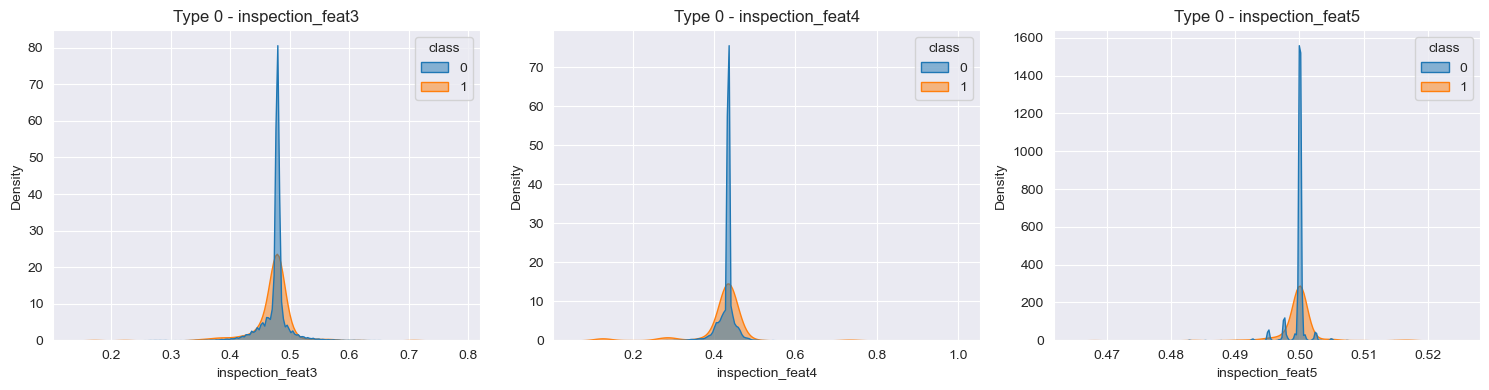


Inspection Type 3: Found 17 Continuous Features


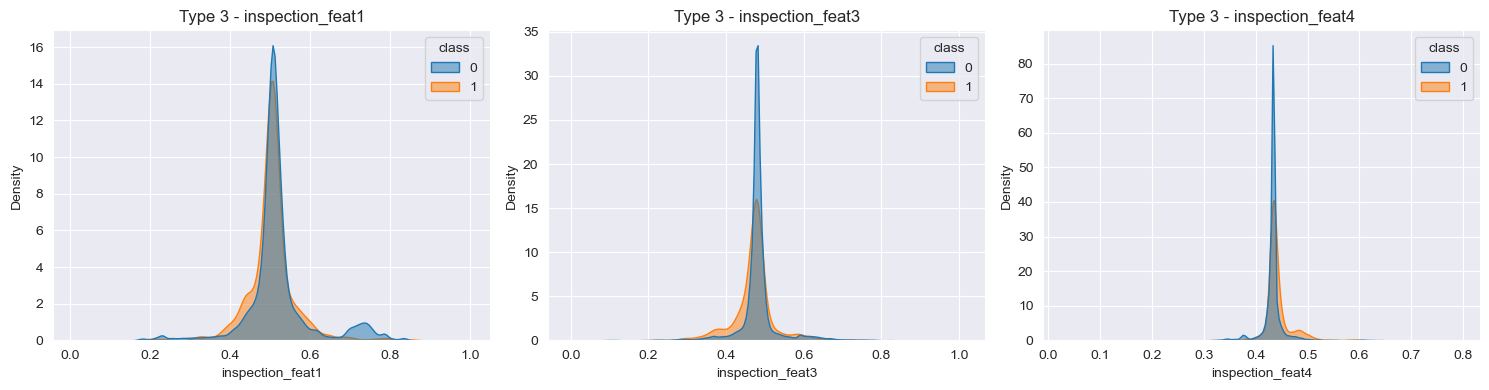


Inspection Type 2: Found 19 Continuous Features


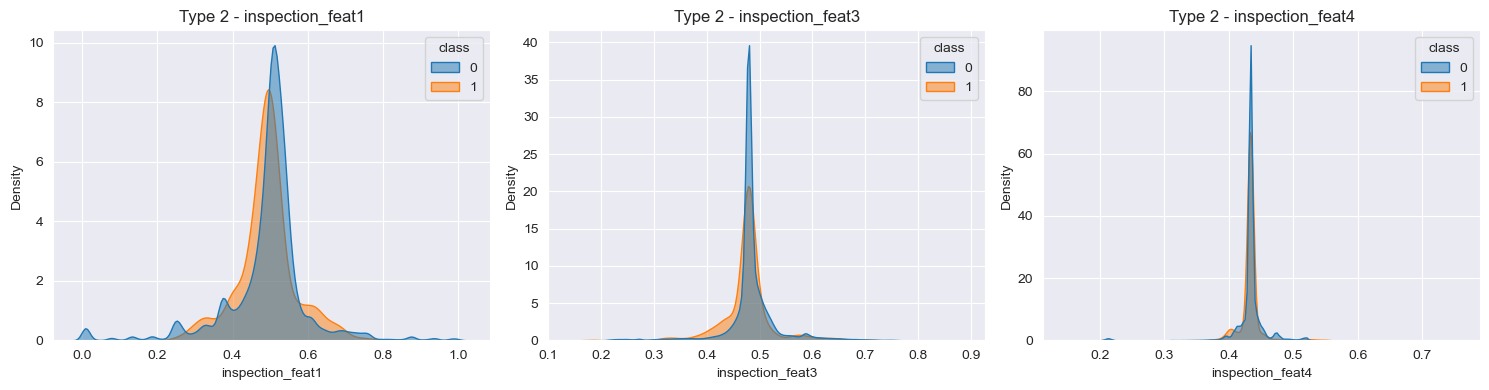


Inspection Type 1: Found 30 Continuous Features


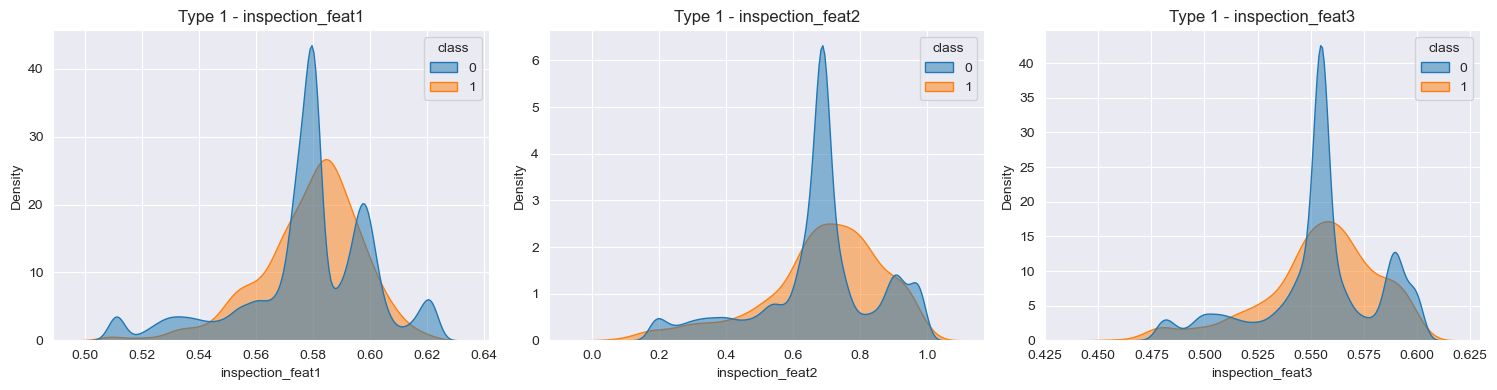


Inspection Type 4: Found 17 Continuous Features


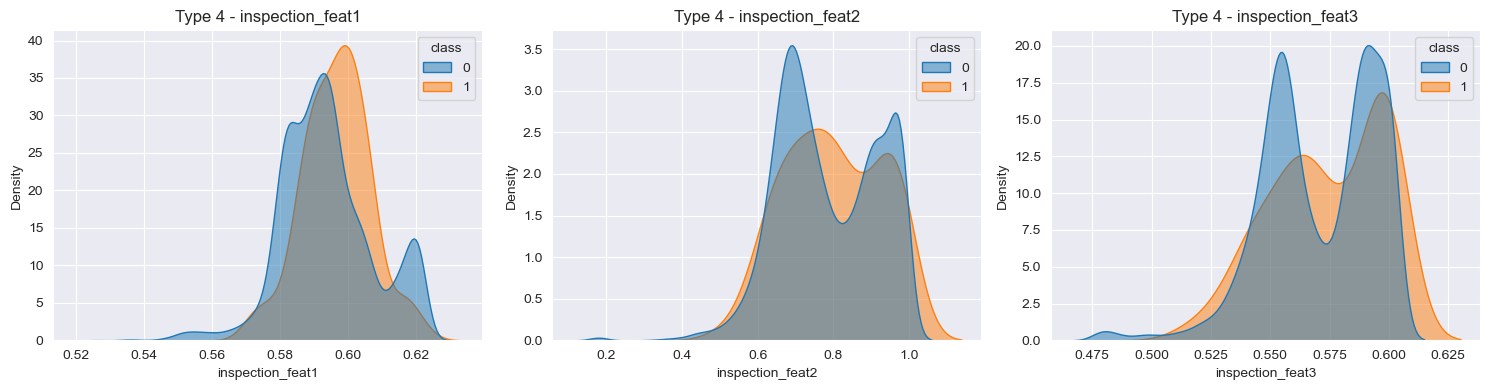

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Identify base continuous features for plotting (per inspection_type)
for itype in df['inspection_type'].unique():
    sub_df = df[df['inspection_type'] == itype]
    
    # Isolate continuous features
    continuous_feats = []
    for col in inspection_feats:
        # Ignore sentinels
        if (sub_df[col] == 0.0).all():
            continue
        # Check if continuous (>20 unique non-zero values)
        if sub_df[sub_df[col] != 0.0][col].nunique() > 20:
            continuous_feats.append(col)
            
    print(f"\n{'='*50}\nInspection Type {itype}: Found {len(continuous_feats)} Continuous Features\n{'='*50}")
    
    # We will plot the first 3 continuous features as a sample to check separability
    feats_to_plot = continuous_feats[:3]
    if not feats_to_plot:
        continue
        
    fig, axes = plt.subplots(1, len(feats_to_plot), figsize=(5 * len(feats_to_plot), 4))
    if len(feats_to_plot) == 1: axes = [axes]
    
    for ax, feat in zip(axes, feats_to_plot):
        # We replace exactly 0.0 with NaN for plotting so sentinels don't skew the visual distribution of actual physical measurements
        plot_df = sub_df[['class', feat]].copy()
        plot_df[feat] = plot_df[feat].replace(0.0, np.nan)
        
        sns.kdeplot(data=plot_df, x=feat, hue='class', common_norm=False, fill=True, alpha=0.5, ax=ax)
        ax.set_title(f"Type {itype} - {feat}")
    
    plt.tight_layout()
    plt.show()


## 9. Feature Engineering & Anomaly Detection Roadmap (Data Science Review)

Based on the extreme class imbalance (99% False Calls), severe label noise (14k contradictory rows), and shifting feature definitions by `inspection_type`, we propose the following dual-track modeling hypothesis:

### A. Supervised Baseline Strategy: CPU Edge XGBoost
1. **Sparsity-Awareness via NaN:** Instead of leaving sentinel values as `0.0`, convert them all to `np.nan`. XGBoost’s built-in sparsity-aware split finding will automatically learn the optimal default direction for these unmeasured (Not Applicable) features, eliminating the noise of treating `0.0` as a valid numeric measurement.
2. **Label Noise Cleansing:** The 14,000 rows with completely contradictory labels will destroy supervised gradient descent. We must drop these contradictory feature vectors from the *training* set (to prevent the model from learning operator confusion) but retain them in the *validation* set to gauge real-world impact.
3. **Implicit Sub-Trees:** Ensure `inspection_type` is robustly one-hot encoded (or explicitly treated as categorical). This allows XGBoost to make early splits on inspection type, acting as an implicit "Mixture of Experts" without the overhead of 5 separate models on a CPU edge device.

### B. Semi-Supervised Strategy: Anomaly Detection (Label Masking)
Given the catastrophic overlap in Inspection Type 4 (where defects perfectly mimic normal data), supervised models will likely fail or just memorize operator mistakes. 

**The AD Hypothesis:** We mask the flawed `class` labels during training and model the pure manifold of "Normal" (False Call) components. Anything that mathematically deviates is flagged. 
1. **Algorithm:** **Isolation Forest (iForest)**. It is O(n), has a tiny memory footprint, and excels on CPU edge devices compared to distance-based metrics.
2. **Type-Conditioned AD Models:** Do NOT train a global Isolation Forest. Because feature distributions change entirely per type, a global model will falsely flag Type 1 components just because they look different from Type 2. We must train **5 separate lightweight Isolation Forests**, one for each `inspection_type`.
3. **Handling Type 4 Overlap:** If Type 4 defects truly are inliers (high density), standard iForest will struggle. We must investigate if the 14k contradictory noisy labels are isolated within Type 4. If Type 4 is just corrupted by bad operator labels, the unsupervised AD approach will actually perform *better* than the flawed supervised metrics suggest.


## EDA Step 4: Feature Selection Focus (Compact XGBoost)
To deploy a lightweight model on a CPU Edge device, we must drastically reduce the feature space. We execute this based on two deterministic criteria per `inspection_type`:
1. **Zero Variance (Sentinels):** Features that are completely 0.0 (Not Applicable).
2. **Multicollinearity (Redundancy):** Continuous features that have an extreme Spearman correlation ($|\rho| > 0.95$) with another feature, indicating they measure the exact same physical property (e.g., Area vs Bounding Box Area).


In [14]:
import pandas as pd
import numpy as np

# In a real environment, we'd use df from earlier. 
# Re-loading here to ensure clean state if run independently.
df_clean = pd.read_csv('E:/pro_newton/제조 AI/팀 과제/siemens_aoi_ML_practice/data/raw/dataset.csv')
inspection_feats = [col for col in df_clean.columns if col.startswith('inspection_feat')]

for itype in df_clean['inspection_type'].unique():
    sub_df = df_clean[df_clean['inspection_type'] == itype][inspection_feats]
    
    # 1. Zero Variance Features
    zero_var_feats = [col for col in inspection_feats if (sub_df[col] == 0.0).all()]
    
    # 2. High Correlation Features
    # Isolate active continuous features to compute correlation
    active_feats = [col for col in inspection_feats if col not in zero_var_feats]
    continuous_feats = [col for col in active_feats if sub_df[sub_df[col] != 0.0][col].nunique() > 20]
    
    # Compute Spearman Correlation matrix (ignores non-linear scaling issues)
    # Mask 0.0 to NaN so sentinels don't artificially inflate correlation
    corr_df = sub_df[continuous_feats].replace(0.0, np.nan)
    corr_matrix = corr_df.corr(method='spearman').abs()
    
    # Find highly correlated pairs (> 0.95)
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_pairs = [
        (col, row) for col in upper_triangle.columns 
        for row in upper_triangle.index if upper_triangle.loc[row, col] > 0.95
    ]
    
    # Deduplicate drops
    features_to_drop_corr = list(set([col for col, row in high_corr_pairs]))
    
    print(f"\n{'='*40}")
    print(f"Inspection Type {itype} - Drop Candidates")
    print(f"{'='*40}")
    print(f"1. Zero Variance (Sentinels) to drop: {len(zero_var_feats)} features")
    print(f"2. Highly Correlated (>0.95) to drop: {len(features_to_drop_corr)} features")
    
    # Example pairs
    if high_corr_pairs:
        print(f"   Example redundant pair: {high_corr_pairs[0][1]} & {high_corr_pairs[0][0]} (corr > 0.95)")
        
    print(f"Total features that can be safely removed for Type {itype}: {len(zero_var_feats) + len(features_to_drop_corr)} / 99")



Inspection Type 0 - Drop Candidates
1. Zero Variance (Sentinels) to drop: 21 features
2. Highly Correlated (>0.95) to drop: 1 features
   Example redundant pair: inspection_feat5 & inspection_feat63 (corr > 0.95)
Total features that can be safely removed for Type 0: 22 / 99

Inspection Type 3 - Drop Candidates
1. Zero Variance (Sentinels) to drop: 39 features
2. Highly Correlated (>0.95) to drop: 0 features
Total features that can be safely removed for Type 3: 39 / 99

Inspection Type 2 - Drop Candidates
1. Zero Variance (Sentinels) to drop: 38 features
2. Highly Correlated (>0.95) to drop: 2 features
   Example redundant pair: inspection_feat9 & inspection_feat10 (corr > 0.95)
Total features that can be safely removed for Type 2: 40 / 99

Inspection Type 1 - Drop Candidates
1. Zero Variance (Sentinels) to drop: 32 features
2. Highly Correlated (>0.95) to drop: 4 features
   Example redundant pair: inspection_feat5 & inspection_feat32 (corr > 0.95)
Total features that can be safely re